# Li2024 Fig. 2 Peierls-Hubbard Plotting

This notebook loads the saved CBE-TDVP data and plots the observables used for Fig. 2 of Li2024: `S_z(x,t)`, `n_ph(x,t)`, bond dimensions, and the error diagnostics saved by `PeierlsHubbardmodel.py`.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

plt.rcParams.update({
    'figure.dpi': 140,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

result_dir = Path.cwd()
data_path = result_dir / 'peierls_hubbard_g1_L100_M500.npz'
data = np.load(data_path)

x = data['x']
time = data['time']
sz = data['sz']
nph = data['nph']
bond_dims = data['bond_dims']
energy = data['energy']
max_discarded_weight = data['max_discarded_weight']
sum_discarded_weight = data['sum_discarded_weight']

print(data_path)
for key in data.files:
    print(f'{key:>22s}: {data[key].shape}')


/curie-home/zengjj/Renormalizer/CBE_202605/PeierlsHubbardmodel/results/peierls_hubbard_g1_L100_M500.npz
                     x: (100,)
                  time: (81,)
                    sz: (81, 100)
                   nph: (81, 100)
                energy: (81,)
             bond_dims: (81, 301)
          bond_entropy: (81, 299)
  max_discarded_weight: (81,)
  sum_discarded_weight: (81,)


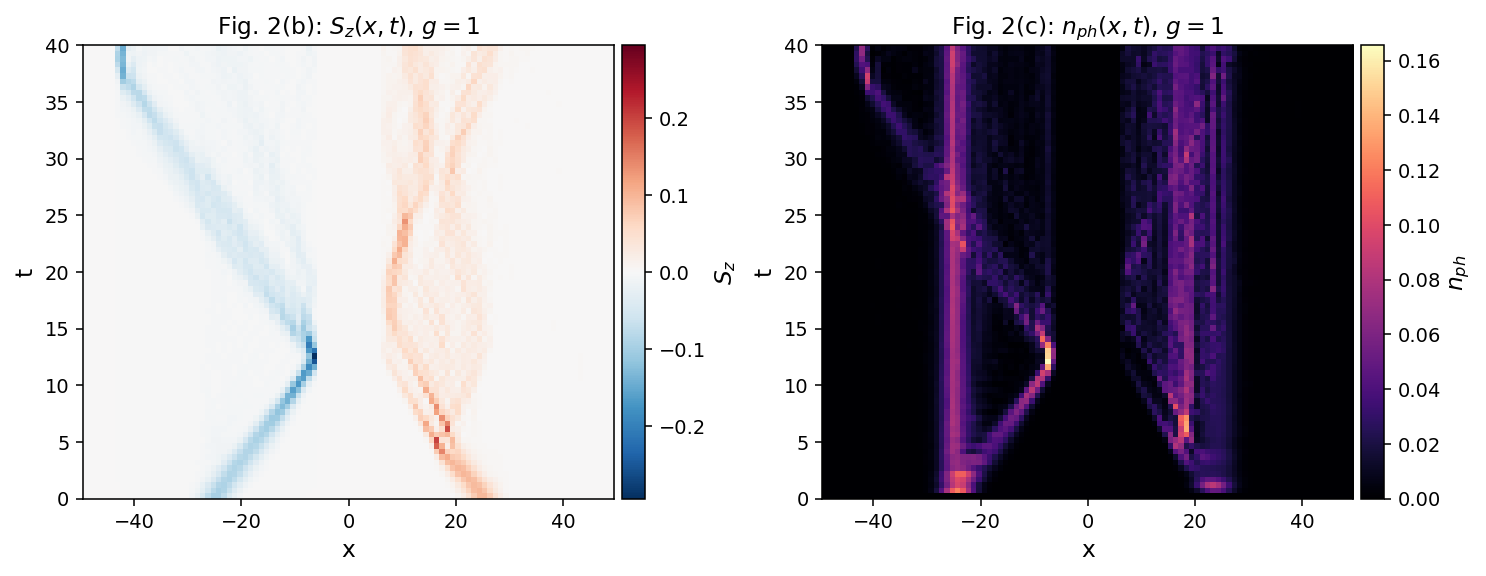

In [2]:
def heatmap(ax, arr, title, cbar_label, cmap, vmin=None, vmax=None):
    im = ax.imshow(
        arr,
        origin='lower',
        aspect='auto',
        interpolation='nearest',
        extent=[x[0], x[-1], time[0], time[-1]],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    cb = plt.colorbar(im, ax=ax, pad=0.015)
    cb.set_label(cbar_label)
    return im

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), constrained_layout=True)
abs_sz = float(np.nanmax(np.abs(sz)))
heatmap(axes[0], sz, r'Fig. 2(b): $S_z(x,t)$, $g=1$', r'$S_z$', 'RdBu_r', -abs_sz, abs_sz)
heatmap(axes[1], nph, r'Fig. 2(c): $n_{ph}(x,t)$, $g=1$', r'$n_{ph}$', 'magma')
plt.show()


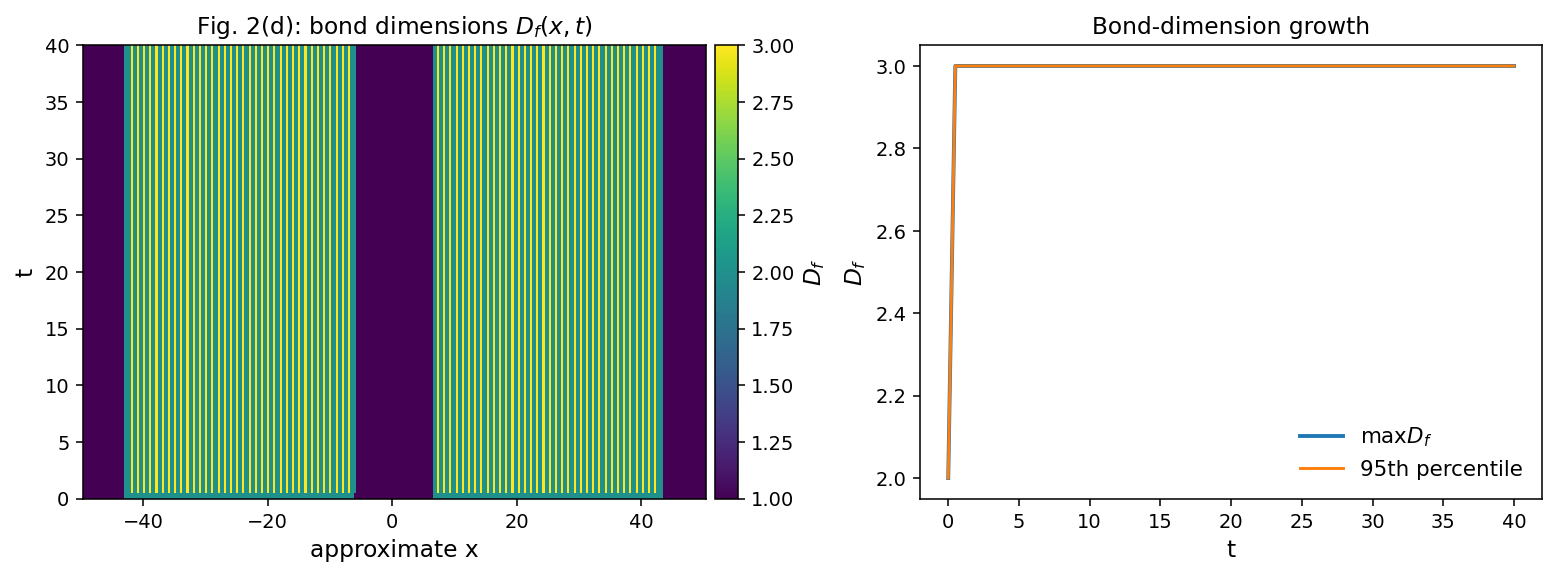

In [3]:
# The MPS ordering in PeierlsHubbardmodel.py is [up, down, phonon] per physical lattice site.
# bond_dims contains the two boundary bonds, so this maps virtual bond index to an approximate lattice coordinate.
bond_index = np.arange(bond_dims.shape[1])
bond_x = (bond_index - 0.5) / 3.0 - (len(x) - 1) / 2.0

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), constrained_layout=True)
im = axes[0].imshow(
    bond_dims,
    origin='lower',
    aspect='auto',
    interpolation='nearest',
    extent=[bond_x[0], bond_x[-1], time[0], time[-1]],
    cmap='viridis',
)
axes[0].set_title(r'Fig. 2(d): bond dimensions $D_f(x,t)$')
axes[0].set_xlabel('approximate x')
axes[0].set_ylabel('t')
cb = plt.colorbar(im, ax=axes[0], pad=0.015)
cb.set_label(r'$D_f$')

axes[1].plot(time, bond_dims.max(axis=1), lw=2, label=r'$\max D_f$')
axes[1].plot(time, np.percentile(bond_dims, 95, axis=1), lw=1.5, label='95th percentile')
axes[1].set_title('Bond-dimension growth')
axes[1].set_xlabel('t')
axes[1].set_ylabel(r'$D_f$')
axes[1].legend(frameon=False)
plt.show()


/tmp/ipykernel_2073037/4020612661.py:18: UserWarning: The label '_child1' of <matplotlib.lines.Line2D object at 0x76d7e408e370> starts with '_'. It is thus excluded from the legend.
  ax1.legend(lines, labels, frameon=False, loc='best')


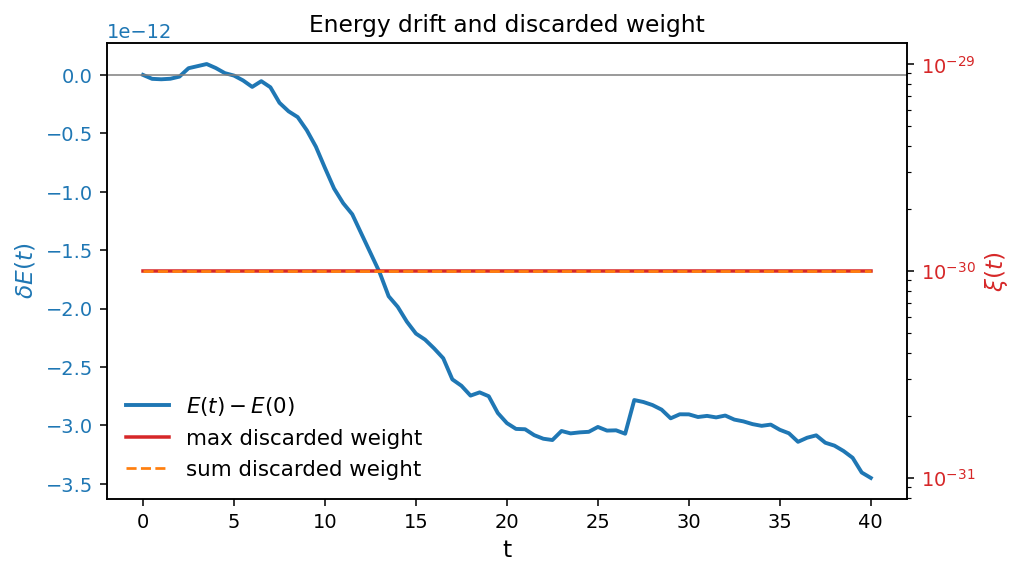

In [4]:
delta_e = energy - energy[0]

fig, ax1 = plt.subplots(figsize=(7.2, 4.0), constrained_layout=True)
ax1.plot(time, delta_e, color='tab:blue', lw=2, label=r'$E(t)-E(0)$')
ax1.set_xlabel('t')
ax1.set_ylabel(r'$\delta E(t)$', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.axhline(0, color='0.5', lw=0.8)

ax2 = ax1.twinx()
ax2.semilogy(time, np.maximum(max_discarded_weight, 1e-30), color='tab:red', lw=1.8, label='max discarded weight')
ax2.semilogy(time, np.maximum(sum_discarded_weight, 1e-30), color='tab:orange', lw=1.4, ls='--', label='sum discarded weight')
ax2.set_ylabel(r'$\xi(t)$', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

lines = ax1.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, frameon=False, loc='best')
ax1.set_title('Energy drift and discarded weight')
plt.show()


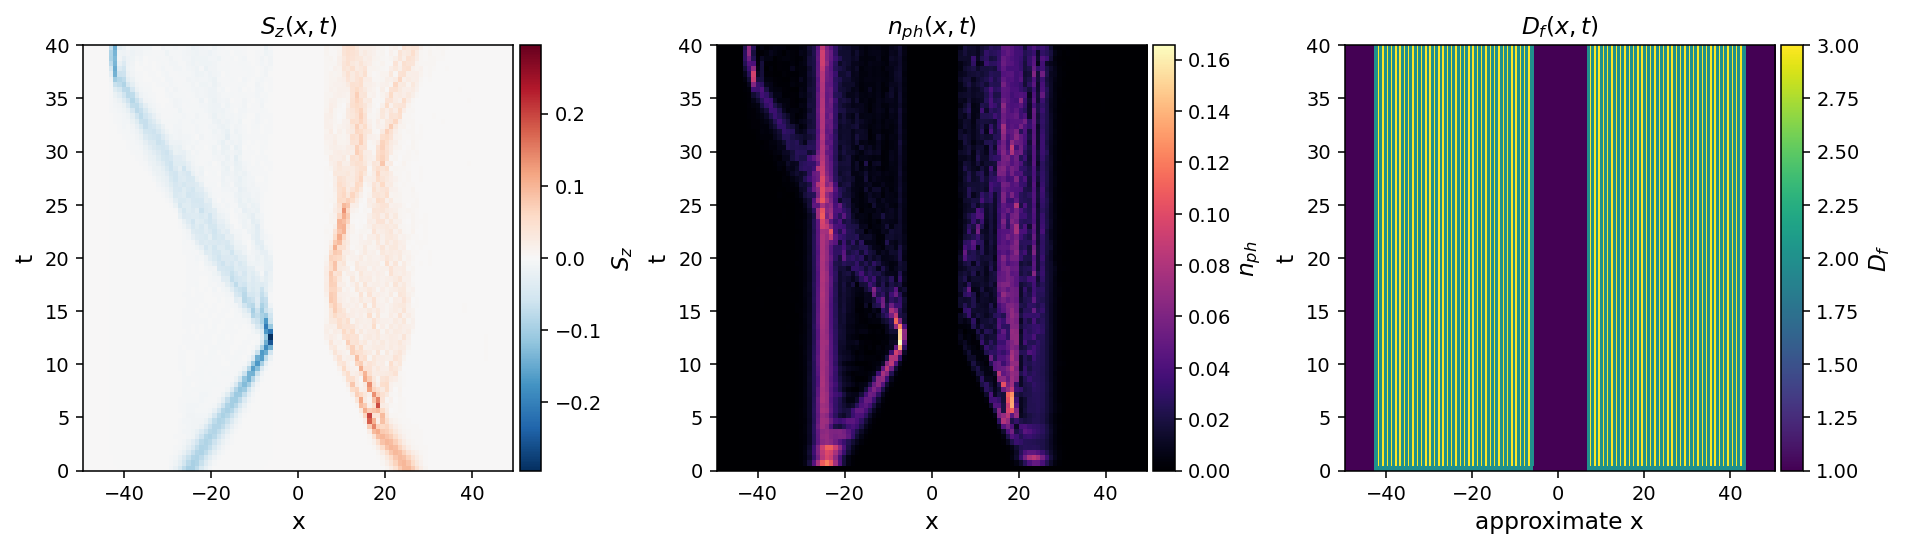

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), constrained_layout=True)
abs_sz = float(np.nanmax(np.abs(sz)))
heatmap(axes[0], sz, r'$S_z(x,t)$', r'$S_z$', 'RdBu_r', -abs_sz, abs_sz)
heatmap(axes[1], nph, r'$n_{ph}(x,t)$', r'$n_{ph}$', 'magma')
im = axes[2].imshow(
    bond_dims, origin='lower', aspect='auto', interpolation='nearest',
    extent=[bond_x[0], bond_x[-1], time[0], time[-1]], cmap='viridis'
)
axes[2].set_title(r'$D_f(x,t)$')
axes[2].set_xlabel('approximate x')
axes[2].set_ylabel('t')
cb = plt.colorbar(im, ax=axes[2], pad=0.015)
cb.set_label(r'$D_f$')
fig.savefig(result_dir / 'fig2_g1_reproduction.png', bbox_inches='tight', dpi=300)
plt.show()
